# EDA - AI4I Predictive Maintenance (Grupo 4)

In [2]:
# ============================================================
# EDA - EXPLORATORY DATA ANALYSIS
# Proyecto: AI4I Predictive Maintenance - MLOps (Grupo 4)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import os

# el notebook corre con cwd en notebooks/, no en la raiz del
# proyecto, entonces si estamos ahi subimos un nivel. esto es
# necesario para poder importar src.data_quality.validate
if Path.cwd().name == "notebooks":
    os.chdir("..")

sys.path.append(str(Path.cwd()))

print("directorio de trabajo:", Path.cwd())

directorio de trabajo: c:\Users\felip\OneDrive\Área de Trabalho\Proyecto_Modulo6\ai4i-mlops


## 2. Cargar el dataset

Reutilizamos `load_raw_data()` de `validate.py` en vez de repetir la
lógica de carga aquí. Así hay una sola fuente de verdad sobre dónde
vive el CSV.

In [3]:
from src.data_quality.validate import load_raw_data

df = load_raw_data()

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
print("Dimensiones del dataset:")
print(df.shape)

print("\nColumnas disponibles:")
for column in df.columns:
    print("-", column)

Dimensiones del dataset:
(10000, 14)

Columnas disponibles:
- UDI
- Product ID
- Type
- Air temperature [K]
- Process temperature [K]
- Rotational speed [rpm]
- Torque [Nm]
- Tool wear [min]
- Machine failure
- TWF
- HDF
- PWF
- OSF
- RNF


## 3. Distribución de la variable objetivo (Machine failure)

In [5]:
failure_counts = df["Machine failure"].value_counts().sort_index()

failure_percentages = (
    df["Machine failure"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("Cantidad de registros por clase:")
print(failure_counts)

print("\nPorcentaje por clase:")
print(failure_percentages.round(2))

Cantidad de registros por clase:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Porcentaje por clase:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


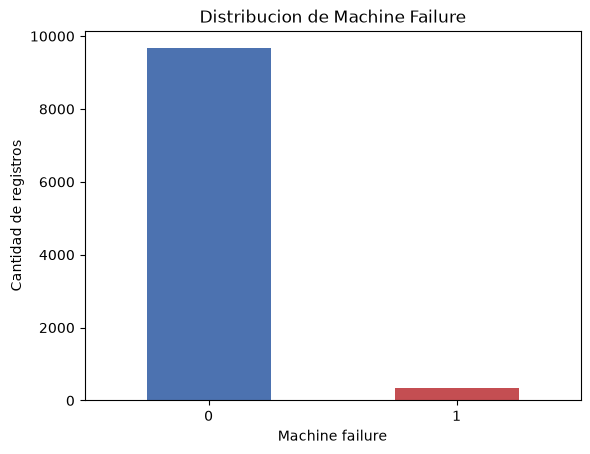

In [6]:
failure_counts.plot(kind="bar", color=["#4C72B0", "#C44E52"])
plt.title("Distribucion de Machine Failure")
plt.xlabel("Machine failure")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=0)
plt.show()

**Decisión:** con 96.61% de máquinas normales y solo 3.39% con falla,
un modelo que prediga siempre "normal" tendría esa misma accuracy sin
detectar ni una sola falla real. Por eso descartamos accuracy como
métrica principal y vamos a usar Precision, Recall, F1, ROC-AUC y
PR-AUC — priorizando el Recall de la clase de falla, porque nos
interesa detectar máquinas problemáticas, no acertar en promedio.

## 4. Análisis de la variable Type

In [7]:
# Type representa la calidad/tipo del producto:
# L = Low, M = Medium, H = High
type_counts = df["Type"].value_counts()

print("Cantidad por tipo:")
print(type_counts)

print("\nPorcentaje por tipo:")
print((df["Type"].value_counts(normalize=True) * 100).round(2))

Cantidad por tipo:
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Porcentaje por tipo:
Type
L    60.00
M    29.97
H    10.03
Name: proportion, dtype: float64


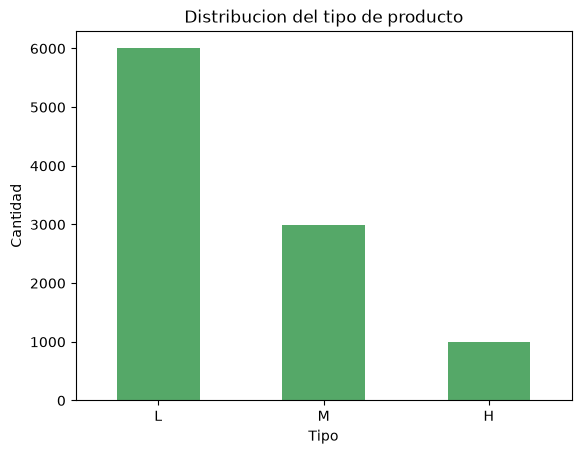

In [8]:
type_counts.plot(kind="bar", color="#55A868")
plt.title("Distribucion del tipo de producto")
plt.xlabel("Tipo")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.show()

Tasa de falla por tipo:
Type
L    3.92
M    2.77
H    2.09
Name: Machine failure, dtype: float64


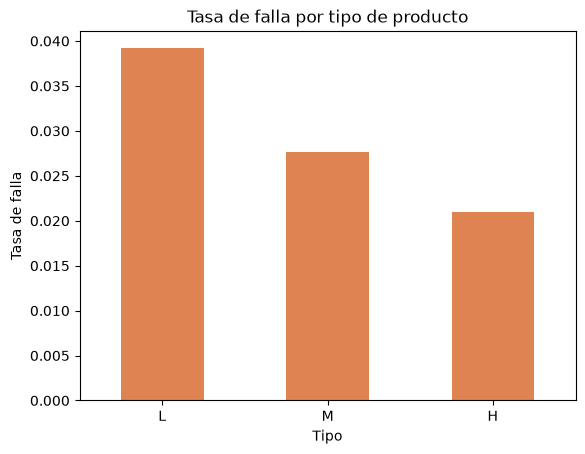

In [9]:
# no basta con ver cuantos hay de cada tipo, hay que ver si el tipo
# realmente se relaciona con la falla, si no, para que lo usamos
tasa_falla_por_tipo = df.groupby("Type")["Machine failure"].mean().sort_values(ascending=False)

print("Tasa de falla por tipo:")
print((tasa_falla_por_tipo * 100).round(2))

tasa_falla_por_tipo.plot(kind="bar", color="#DD8452")
plt.title("Tasa de falla por tipo de producto")
plt.xlabel("Tipo")
plt.ylabel("Tasa de falla")
plt.xticks(rotation=0)
plt.show()

**Decisión:** Type es categórica, así que en feature engineering la
vamos a convertir con OneHotEncoder dentro de un Pipeline de
Scikit-learn (no manualmente L=0, M=1, H=2, porque eso inventaría una
relación de orden que no existe realmente entre los tipos).

Además, cruzándola contra el target vemos que sí aporta señal: el
tipo L falla casi el doble que el tipo H (3.92% vs 2.09%). Eso
confirma que vale la pena mantenerla como feature y no descartarla
como si fuera solo un dato administrativo.

## 5. Definir variables numéricas

In [11]:
# ojo: los nombres reales llevan la unidad entre corchetes
# (ej. "Torque [Nm]", no solo "Torque"), ya los vimos en la seccion 2
numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

df[numeric_features].describe().round(2)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.0,10000.00,10000.00,10000.00,10000.00
mean,300.0,310.01,1538.78,39.99,107.95
std,2.0,1.48,179.28,9.97,63.65
min,295.3,305.70,1168.00,3.80,0.00
25%,298.3,308.80,1423.00,33.20,53.00
50%,300.1,310.10,1503.00,40.10,108.00
75%,301.5,311.10,1612.00,46.80,162.00
max,304.5,313.80,2886.00,76.60,253.00


**Decisión:** los rangos confirman lo que ya vimos en validate.py:
Torque y Rotational speed tienen un salto grande entre el percentil
75 y el maximo (Torque va de 46.8 a 76.6, Rotational speed de 1612 a
2886), coincide con los outliers que ya habiamos detectado con
check_outliers(). No hay ningun valor fuera de rango imposible
(tambien confirmado antes con check_impossible_values), asi que no
hace falta corregir nada aca, solo se toma en cuenta para la siguiente
seccion de outliers.

## 6. Distribución de las variables numéricas

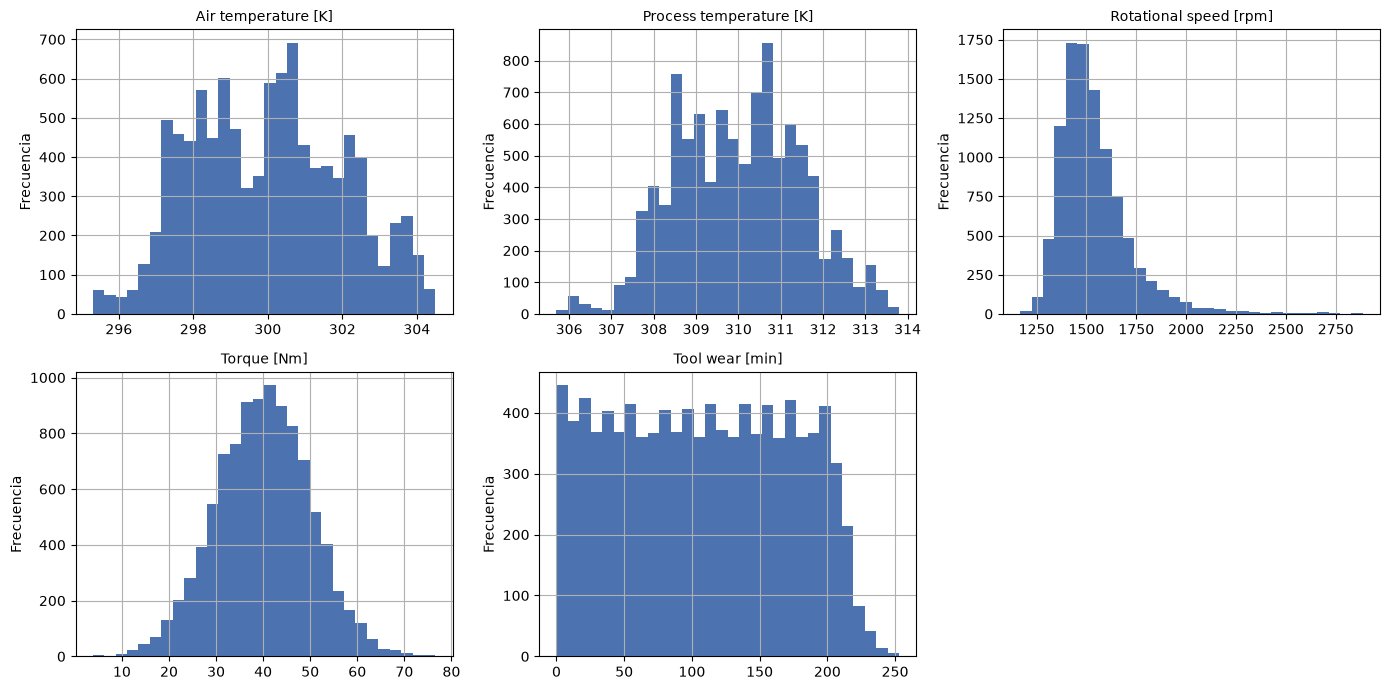

In [12]:
# graficamos las 5 variables juntas en una sola figura,
# mas facil de comparar que 5 celdas separadas
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    df[col].hist(bins=30, ax=axes[i], color="#4C72B0")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel("Frecuencia")

fig.delaxes(axes[-1])  # sobra un eje, son 5 variables en grid de 6
plt.tight_layout()
plt.show()

In [13]:
from src.data_quality.validate import check_skewness

skew_resultado = check_skewness(df)
for col, info in skew_resultado.items():
    print(f"{col}: skewness={info['skewness']}  ({info['interpretacion']})")

Air temperature [K]: skewness=0.114  (simetrica)
Process temperature [K]: skewness=0.015  (simetrica)
Rotational speed [rpm]: skewness=1.993  (muy sesgada)
Torque [Nm]: skewness=-0.01  (simetrica)
Tool wear [min]: skewness=0.027  (simetrica)


**Decisión:** Rotational speed sale bastante desbalanceada (no
simetrica), el resto de variables se ven normales. Se deja anotado
para el equipo de modelado, porque algunos algoritmos de deteccion de
anomalias son sensibles a esto y otros no, dependiendo de cual se
elija finalmente podria valer la pena ajustar esa variable antes de
entrenar.